In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from lark.parsers.earley_forest import handles_ambiguity

### 1.1 Chargement du Dataset

In [2]:
df = pd.read_csv('../data/customer_churn_dataset.csv')

### Visualisation 1 : Distribution du Churn (Diagramme en Barres)

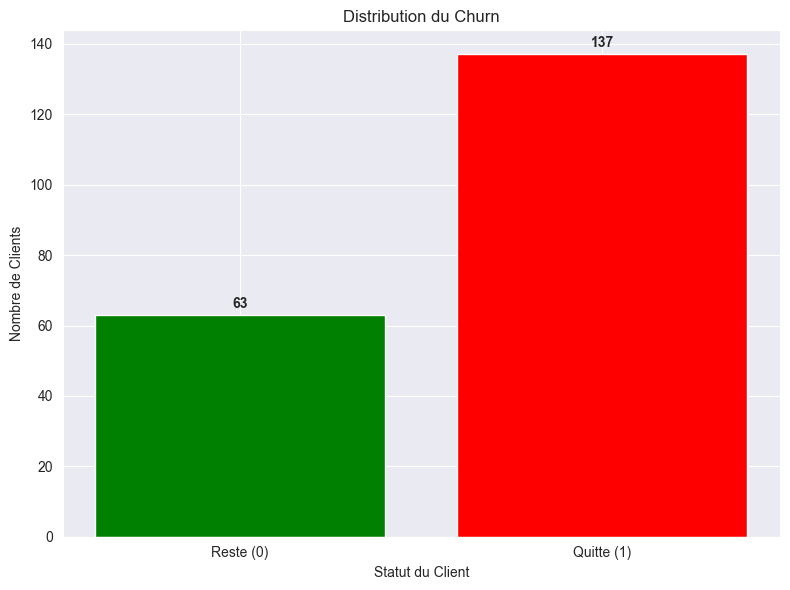

In [3]:
plt.figure(figsize=(8,6))

churn_counts = df['Churn'].value_counts().sort_index()
colors = ['green', 'red']

plt.bar(['Reste (0)', 'Quitte (1)'],churn_counts.values, color = colors)
plt.xlabel('Statut du Client')
plt.ylabel('Nombre de Clients')
plt.title('Distribution du Churn')

for i, v in enumerate(churn_counts.values):
    plt.text(i, v + 2, str(v), ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

### Visualisation 2 : Appels au Support vs Churn (Boîte à Moustaches)

<Figure size 800x600 with 0 Axes>

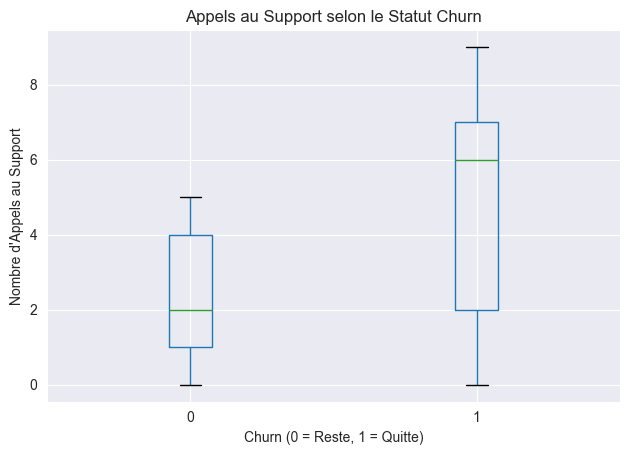

In [4]:
plt.figure(figsize=(8, 6))

df.boxplot(column='Customer_Support_Calls', by='Churn')

plt.xlabel('Churn (0 = Reste, 1 = Quitte)')
plt.ylabel("Nombre d'Appels au Support")
plt.title('Appels au Support selon le Statut Churn')
plt.suptitle('')

plt.tight_layout()
plt.show()

### Visualisation 3 : Retard de Paiement vs Churn (Boîte à Moustaches)

<Figure size 800x600 with 0 Axes>

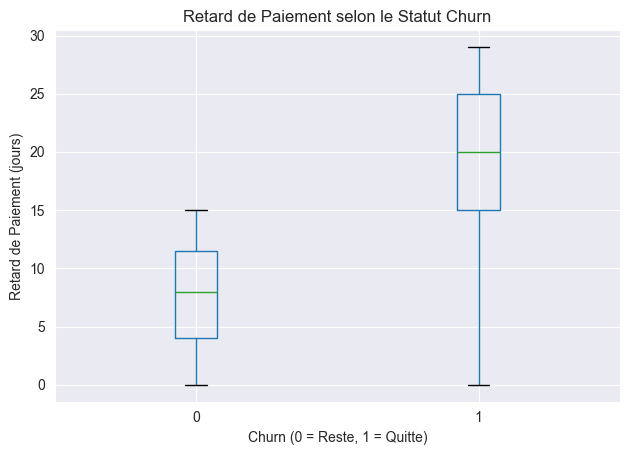

In [5]:
plt.figure(figsize=(8, 6))

df.boxplot(column='Payment_Delay', by='Churn')

plt.xlabel('Churn (0 = Reste, 1 = Quitte)')
plt.ylabel('Retard de Paiement (jours)')
plt.title('Retard de Paiement selon le Statut Churn')
plt.suptitle('')

plt.tight_layout()
plt.show()

### Visualisation 4 : Utilisation Mensuelle vs Retard de Paiement (Nuage de Points)

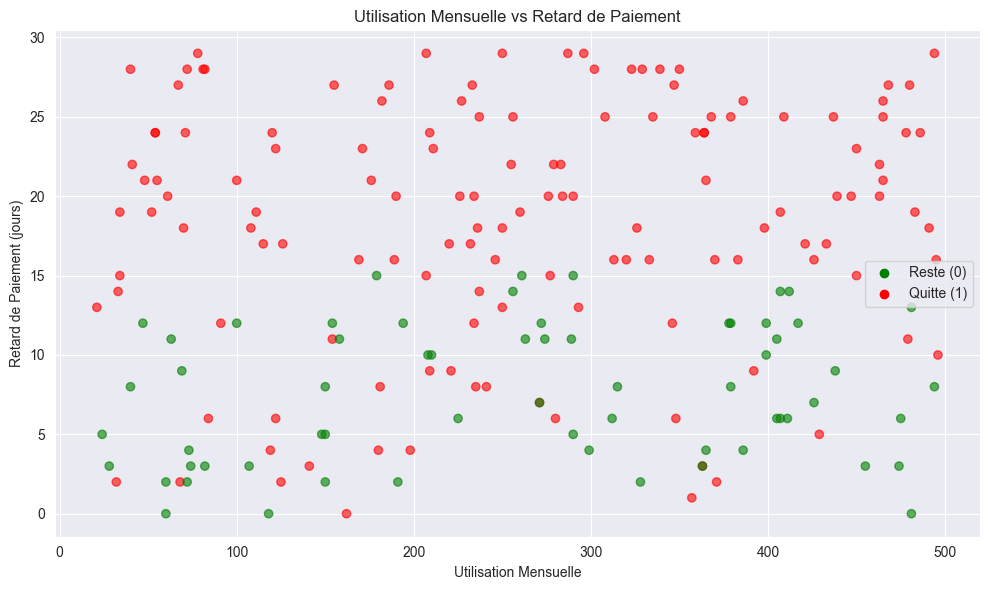

In [6]:
plt.figure(figsize=(10, 6))

colors = ['green' if x == 0 else 'red' for x in df['Churn']]

plt.scatter(df['Monthly_Usage'], df['Payment_Delay'], c=colors, alpha=0.6)
plt.xlabel('Utilisation Mensuelle')
plt.ylabel('Retard de Paiement (jours)')
plt.title('Utilisation Mensuelle vs Retard de Paiement')

plt.legend(handles=[
    plt.scatter([], [], c='green', label='Reste (0)'),
    plt.scatter([], [], c='red', label='Quitte (1)')
])

plt.tight_layout()
plt.show()

### Visualisation 5 : Matrice de Corrélation (Heatmap)

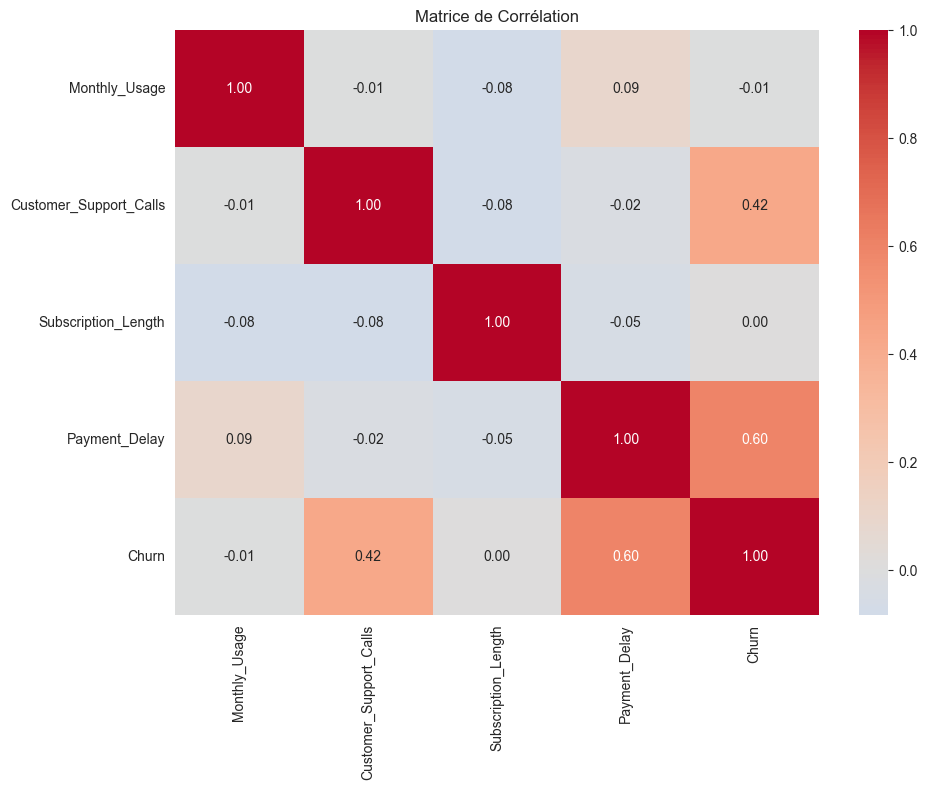

In [7]:
plt.figure(figsize=(10, 8))

correlation = df.corr()

sns.heatmap(correlation, annot=True, cmap='coolwarm', center=0, fmt='.2f')

plt.title('Matrice de Corrélation')

plt.tight_layout()
plt.show()

### Résumé des Visualisations

**Observations clés:**

1. **Distribution du Churn:** Dataset déséquilibré (68.5% quittent vs 31.5% restent)

2. **Appels au Support:** Les clients qui quittent appellent plus souvent le support

3. **Retard de Paiement:** Les clients qui quittent ont un retard de paiement plus élevé

4. **Corrélation:** Payment_Delay et Customer_Support_Calls sont les plus corrélés avec le Churn